In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns


Splitting data into stratified groups where identical patient ids belong to same groups.

Runs Pearson correlation first on correlation between the different features to test if any features are redundant.
After this we prioritise features based on their correlation with diagnosis.

In [ ]:
path = "../../data/Metadata_features/metadata_features.csv"

df = pd.read_csv(path)


X = df[['melanoma_color_count','hue_variance',
 'saturation_variance','value_variance','mabrouk_asymmetry_score',
 'avg_asymmetry_score','worst_score','Polsby-Popper','convexity_score',
 'lesion_red_share','lesion_green_share','lesion_blue_share',
 'lesion_skin_red_diff','lesion_skin_green_diff','lesion_skin_blue_diff',
 'lesion_skin_rgb_distance']]
y = df["skin_cancer_diagnosis"]


# Smaller df grouped by patiend_id
patient_labels = df.groupby("patient_id")["skin_cancer_diagnosis"].max()

patients = patient_labels.index
labels = patient_labels.values

# Splits by patiend id and stratify by patients using .max() to check if patient have a cancerous lesion. 
# First split: train vs test+val
train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


train_mask = df["patient_id"].isin(train_patients)
test_mask = df["patient_id"].isin(test_patients)


X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

# Check distribution of rows in each split
total_rows = len(df)

threshold = 0.8
max_allowed = 3
corr = X_train.corr().abs().fillna(0)
counts = (corr > threshold).sum(axis=1) - 1
to_drop = counts[counts > max_allowed].index.tolist()
X_reduced = X_train.drop(columns=to_drop)

# rank by absolute correlation with label and pick top 10
label_col = "Skin_cancer_diagnosis"
df_rank = X_reduced.copy()
df_rank[label_col] = y_train
corr_with_label = df_rank.corr().abs()[label_col].drop(label_col).fillna(0)
top10 = corr_with_label.sort_values(ascending=False).head(10).index.tolist()

X_train = X_train[top10]
X_test = X_test[top10]

y = df['skin_cancer_diagnosis']

In [ ]:
print("X split distribution:")
print("Train:", round(len(X_train) / total_rows, 3))
print("Test:", round(len(X_test) / total_rows, 3))

# Check cancer vs non-cancer distribution in each split
print("\nTrain cancer distribution:")
print(y_train.value_counts().sort_index())
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest cancer distribution:")
print(y_test.value_counts().sort_index())
print(y_test.value_counts(normalize=True).sort_index())

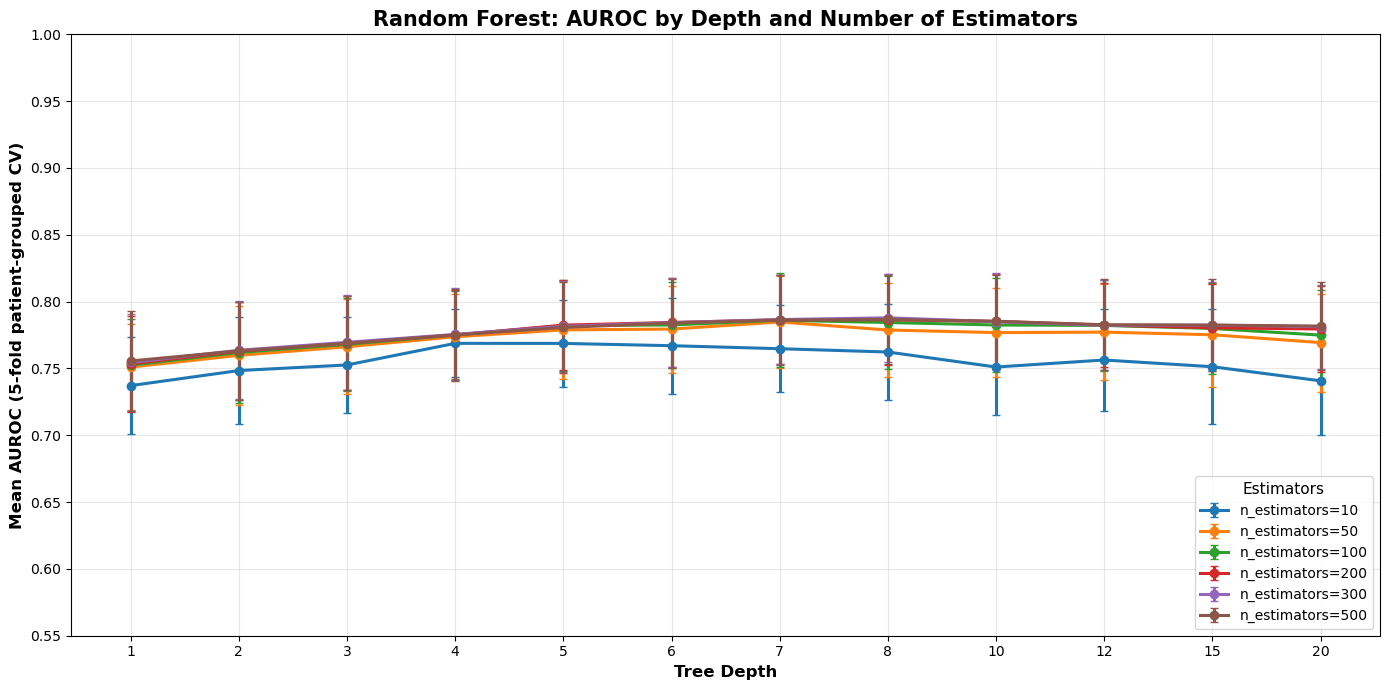

In [106]:
groups_train = df.loc[X_train.index, "patient_id"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
estimators = [10, 50, 100, 200, 300, 500]

mean_auc = {n: [] for n in estimators}
std_auc = {n: [] for n in estimators}

for n in estimators:
    for depth in depths:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        scores = cross_val_score(
            rf,
            X_train,
            y_train,
            cv=cv,
            groups=groups_train,
            scoring='roc_auc',
            n_jobs=-1
        )

        mean_auc[n].append(scores.mean())
        std_auc[n].append(scores.std())

x_positions = list(range(len(depths)))
labels = [str(d) for d in depths]

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, n in enumerate(estimators):
    ax.errorbar(
        x_positions,
        mean_auc[n],
        yerr=std_auc[n],
        fmt='-o',
        capsize=3,
        linewidth=2.2,
        markersize=6,
        color=colors[i],
        label=f'n_estimators={n}'
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.set_xlabel('Tree Depth', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean AUROC (5-fold patient-grouped CV)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: AUROC by Depth and Number of Estimators', fontsize=15, fontweight='bold')
ax.legend(title='Estimators', fontsize=10, title_fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.55, 1])

plt.tight_layout()
plt.show()

For finetuning and trying different depths, estimators and weight based on observations.

In [107]:
# Patient groups for the training data
groups_train = df.loc[X_train.index, "patient_id"]

# Cross-validation that keeps each patient in only one fold
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model to evaluate
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

# Cross-validation scores
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    groups=groups_train,
    scoring="roc_auc"
)

print("ROC AUC scores:", scores)
print(f"Mean ROC AUC: {scores.mean():.4f}")
print(f"Std ROC AUC: {scores.std():.4f}")

ROC AUC scores: [0.80312354 0.73434738 0.77197452 0.83409797 0.77628299]
Mean ROC AUC: 0.7840
Std ROC AUC: 0.0333


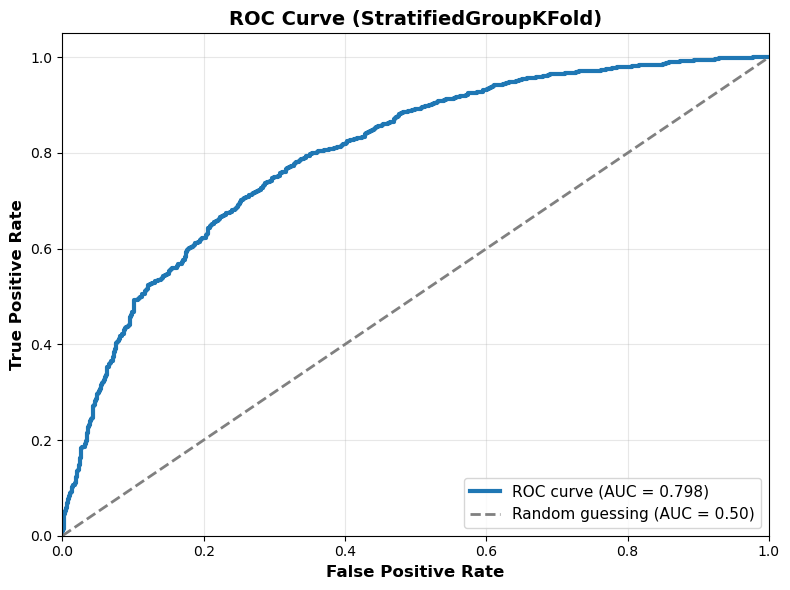

ROC AUC = 0.7982


In [ ]:
groups = df["patient_id"]

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_true_all = []
y_proba_all = []

for train_idx, test_idx in cv.split(X_train, y_train, groups):

    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_tr, y_tr)

    y_pred_proba = model.predict_proba(X_te)[:, 1]

    y_true_all.extend(y_te)
    y_proba_all.extend(y_pred_proba)

y_true_all = np.array(y_true_all)
y_proba_all = np.array(y_proba_all)

fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', linewidth=3,
         label=f'ROC curve (AUC = {roc_auc_value:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2,
         label='Random guessing (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve (StratifiedGroupKFold)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f'ROC AUC = {roc_auc_value:.4f}')

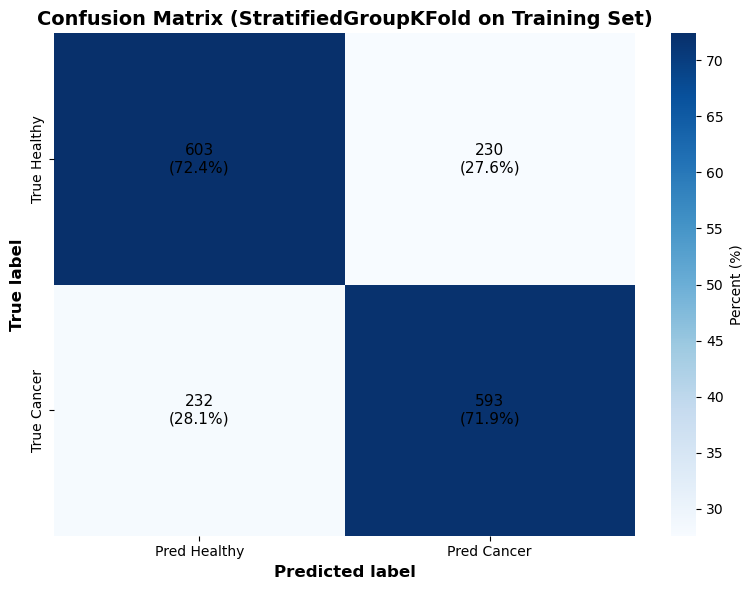

In [115]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_true_all = []
y_pred_all = []

for train_idx, val_idx in cv.split(X_train, y_train, groups_train):

    X_tr = X_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val_fold = y_train.iloc[val_idx]

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val_fold)

    y_true_all.extend(y_val_fold)
    y_pred_all.extend(y_pred)

# convert to arrays
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

labels = ['Healthy', 'Cancer']

# plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_pct,
    annot=False,
    cmap='Blues',
    cbar=True,
    xticklabels=[f'Pred {l}' for l in labels],
    yticklabels=[f'True {l}' for l in labels],
    cbar_kws={'label': 'Percent (%)'}
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j + 0.5,
            i + 0.5,
            f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)',
            ha='center',
            va='center',
            color='black',
            fontsize=11
        )

plt.xlabel('Predicted label', fontsize=12, fontweight='bold')
plt.ylabel('True label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix (StratifiedGroupKFold on Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()